In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# -----------------------
# 1) Set global parameters
# -----------------------
N_STUDENTS = 8000
WEEKS = np.arange(1, 13)         # 1..12
POST_START = 7                   # weeks 7..12 are post
N_ASSIGNMENTS = 5                # per week

# SES distribution
ses_levels = ["low", "mid", "high"]
ses_probs = [0.30, 0.45, 0.25]

# Grades
grades = np.arange(6, 13)

# -----------------------
# 2) Create student table
# -----------------------
students = pd.DataFrame({
    "student_id": np.arange(1, N_STUDENTS + 1),
    "grade_level": rng.choice(grades, size=N_STUDENTS, replace=True),
    "ses_band": rng.choice(ses_levels, size=N_STUDENTS, p=ses_probs, replace=True),
})

# Baseline score: Normal(70,10) clipped [40,95]
baseline_score = rng.normal(70, 10, size=N_STUDENTS)
students["baseline_score"] = np.clip(baseline_score, 40, 95)

# Baseline engagement: Normal(3.5,1.0) clipped [0,7]
baseline_eng = rng.normal(3.5, 1.0, size=N_STUDENTS)
students["baseline_engagement"] = np.clip(baseline_eng, 0, 7)

# Optional: make baseline_engagement correlate a bit with baseline_score and SES
ses_shift = students["ses_band"].map({"low": -0.3, "mid": 0.0, "high": 0.3}).to_numpy()
students["baseline_engagement"] = np.clip(
    students["baseline_engagement"] + 0.02*(students["baseline_score"]-70) + ses_shift,
    0, 7
)

# -----------------------
# 3) Stratified randomization (grade_level × ses_band)
# -----------------------
students["stratum"] = students["grade_level"].astype(str) + "_" + students["ses_band"].astype(str)
students["treatment"] = False

for stratum, idx in students.groupby("stratum").groups.items():
    idx = np.array(list(idx))
    rng.shuffle(idx)
    half = len(idx) // 2
    treat_idx = idx[:half]
    students.loc[treat_idx, "treatment"] = True

# -----------------------
# 4) Expand to student-week panel
# -----------------------
panel = students.loc[:, ["student_id", "grade_level", "ses_band", "baseline_score", "baseline_engagement", "treatment"]].merge(
    pd.DataFrame({"week": WEEKS}),
    how="cross"
)

panel["post_period"] = panel["week"] >= POST_START

# -----------------------
# 5) Generate engagement outcomes with realism
# -----------------------
# Time trend: mild fatigue over weeks
# e.g., -0.05 active days per week after week 1
fatigue = -0.05 * (panel["week"] - 1)

# SES effect on engagement
ses_eng = panel["ses_band"].map({"low": -0.2, "mid": 0.0, "high": 0.2}).to_numpy()

# Baseline-engagement as mean driver for active days
mu_active = panel["baseline_engagement"].to_numpy() + fatigue + ses_eng

# Treatment effect: only post; stronger for low baseline engagement, ceiling effects
low_base = (panel["baseline_engagement"] < 3.0).to_numpy()
high_base = (panel["baseline_engagement"] > 5.5).to_numpy()

treat = panel["treatment"].to_numpy()
post = panel["post_period"].to_numpy()

treat_effect = np.zeros(len(panel))
treat_effect += post * treat * 0.30
treat_effect += post * treat * low_base * 0.30   # extra for low baseline => total 0.60
treat_effect -= post * treat * high_base * 0.20  # reduce for high baseline => ~0.10

mu_active = mu_active + treat_effect

# Convert to integer 0..7; use Poisson-ish then clip
# (Poisson expects non-negative rate; add floor)
lam = np.clip(mu_active, 0.1, 7.0)
active_days = rng.poisson(lam)
panel["weekly_active_days"] = np.clip(active_days, 0, 7)

# Assignments completed: Binomial(n=5, p depends on active days)
p_complete = np.clip(panel["weekly_active_days"] / 7 * 0.9 + 0.05, 0.02, 0.98)
panel["assignments_completed"] = rng.binomial(N_ASSIGNMENTS, p_complete)

# Engagement index: transparent composite
panel["engagement_index"] = 0.5 * panel["weekly_active_days"] + 0.5 * panel["assignments_completed"]

# -----------------------
# 6) Generate assessment outcome (small effect, noisy, some regression-to-mean)
# -----------------------
# Regression to mean: students with high baseline drift slightly down, low drift up
rtm = -0.10 * (panel["baseline_score"] - 70)

# Week-to-week noise
score_noise = rng.normal(0, 4.0, size=len(panel))

# Modest improvement post for all (e.g., general learning growth)
general_growth = panel["week"].to_numpy() * 0.15

# Treatment effect post: +1.5 average, slightly larger for low baseline engagement
score_treat = post * treat * (1.2 + 0.6 * low_base)  # avg ~1.5-ish

score = panel["baseline_score"].to_numpy() + rtm + general_growth + score_treat + score_noise
panel["assessment_score"] = np.clip(score, 0, 100)

# -----------------------
# 7) Missingness (realism): some students missing some weeks
# -----------------------
# Example: 8% chance student-week missing in low SES, 5% mid, 3% high
miss_prob = panel["ses_band"].map({"low": 0.08, "mid": 0.05, "high": 0.03}).to_numpy()
missing = rng.random(len(panel)) < miss_prob
panel = panel.loc[~missing].reset_index(drop=True)

# -----------------------
# 8) Save dataset
# -----------------------
panel.to_csv("data/synthetic_student_week_data.csv", index=False)

In [2]:
df = panel.copy()  # or: df = pd.read_csv("data/synthetic_student_week_data.csv")

# One row per student for baseline covariates
stu = (df.sort_values(["student_id", "week"])
         .groupby("student_id", as_index=False)
         .first()[["student_id", "treatment", "grade_level", "ses_band", "baseline_score", "baseline_engagement"]])

balance_numeric = (stu.groupby("treatment")[["baseline_score", "baseline_engagement"]]
                     .agg(["mean", "std", "count"])
                     .round(3))

ses_mix = (pd.crosstab(stu["ses_band"], stu["treatment"], normalize="columns")
             .rename(columns={False: "control_share", True: "treat_share"})
             .round(3))

grade_mix = (pd.crosstab(stu["grade_level"], stu["treatment"], normalize="columns")
               .rename(columns={False: "control_share", True: "treat_share"})
               .round(3))

print("Numeric balance (baseline):")
display(balance_numeric)
print("\nSES mix (share within group):")
display(ses_mix)
print("\nGrade mix (share within group):")
display(grade_mix)

Numeric balance (baseline):


baseline_score               baseline_engagement             
                    mean     std count                mean    std count
treatment                                                              
False             70.212   9.824  4005               3.527  1.039  4005
True              70.220  10.109  3995               3.509  1.044  3995


SES mix (share within group):


treatment,control_share,treat_share
ses_band,,
high,0.241,0.241
low,0.303,0.303
mid,0.456,0.457



Grade mix (share within group):


treatment,control_share,treat_share
grade_level,,
6,0.145,0.145
7,0.147,0.146
8,0.142,0.142
9,0.151,0.151
10,0.133,0.133
11,0.146,0.146
12,0.137,0.137


In [3]:
pre = df[df["post_period"] == False].copy()

pre_summary = (pre.groupby("treatment")[["weekly_active_days", "assignments_completed", "engagement_index", "assessment_score"]]
                 .mean()
                 .rename(index={False: "control_pre", True: "treat_pre"})
                 .round(3))

pre_diff = (pre.groupby("treatment")[["weekly_active_days", "assignments_completed", "engagement_index", "assessment_score"]]
              .mean()
              .pipe(lambda x: x.loc[True] - x.loc[False])
              .to_frame("treat_minus_control_pre")
              .round(3))

display(pre_summary)
display(pre_diff)


,weekly_active_days,assignments_completed,engagement_index,assessment_score
treatment,,,,
control_pre,3.315,2.382,2.848,70.664
treat_pre,3.296,2.365,2.830,70.670


,treat_minus_control_pre
weekly_active_days,-0.019
assignments_completed,-0.017
engagement_index,-0.018
assessment_score,0.006


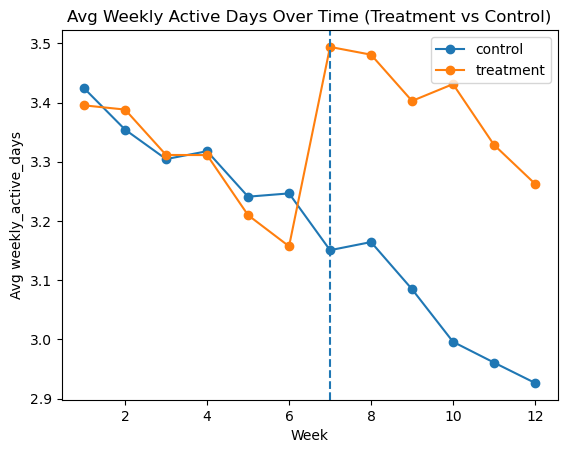

In [4]:
trend = (df.groupby(["week", "treatment"], as_index=False)["weekly_active_days"]
           .mean()
           .sort_values(["week", "treatment"]))

for key, g in trend.groupby("treatment"):
    label = "treatment" if key else "control"
    plt.plot(g["week"], g["weekly_active_days"], marker="o", label=label)

plt.axvline(x=7, linestyle="--")
plt.title("Avg Weekly Active Days Over Time (Treatment vs Control)")
plt.xlabel("Week")
plt.ylabel("Avg weekly_active_days")
plt.legend()
plt.show()
